# Basic Example using MOGPTK

Fit a multi-output spectral mixture GP to a simple two-band example. Bands are similar sinusoids but with a known phase difference plus some Gaussian noise.

In [1]:
import mogptk
import torch
import numpy as np
import matplotlib.pyplot as plt

#torch.manual_seed(0);

/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


The MOSM kernel has the form (Definition 5; Parra & Tobar 2017):

$$k_{ij}(\tau) = \sum_{q=1}^Q \alpha^{(q)}_{ij} \exp \left( -\frac{1}{2} (\tau + \theta^{(q)}_{ij})^\top \Sigma^{(q)}_{ij}(\tau + \theta^{(q)}_{ij}) \right) \cos \left( (\tau + \theta^{(q)}_{ij})^\top \mu^{(q)}_{ij} + \phi^{(q)}_{ij} \right), \qquad \alpha^{(q)}_{ij} = w^{(q)}_{ij} (2\pi)^{n/2} | \Sigma^{(q)}_{ij} |^{1/2} $$

- No. of spectral mixture components: $Q$
- parameter of $q$ th mixture component: $(.)^{(q)}$
- Covariance: $\Sigma_{ij}$
- Mean: $\mu_{ij}$
- Magnitude (weight of component): $w_{ij}$
- Delay: $\theta_{ij} = \theta_i - \theta_j$
- Phase: $\phi_{ij} = \phi_i - \phi_j$

**NB:** the above parameters describe the shape of the kernel in the *spectral* domain.

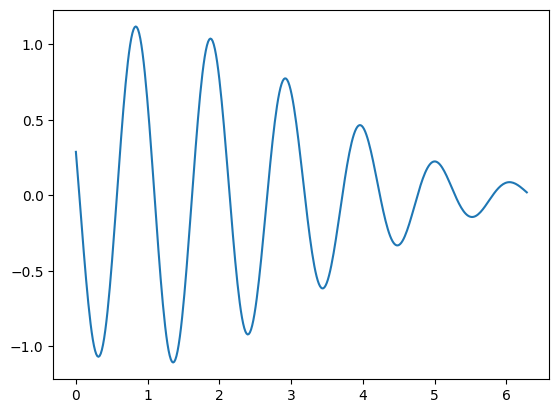

In [2]:
# Plot one-dimensional, single-component MOSM kernel in time domain
def plot_k(taus, w_mag, sigma_cov, theta_delay, mu_freq, phi_phase):
    alpha = w_mag * (2*np.pi)**0.5 * np.abs(sigma_cov)**0.5
    k = alpha*np.exp(-0.5*(taus+theta_delay)**2*sigma_cov) * np.cos( (taus+theta_delay)*mu_freq + phi_phase)

    plt.plot(taus, k)

taus = np.linspace(0, 2*np.pi, 400)
plot_k(taus, w_mag=1, sigma_cov=1/5, theta_delay=-1, mu_freq=6, phi_phase=1)

For a MOSM GP with a single mixture component (Q = 1), the $i^\mathrm{th}$ diagonal submatrix corresponding to the $i^\mathrm{th}$ band ($i = j$, $\theta_{ii} = 0$, $\phi_{ii} = 0$) is a SE $\times$ cosine autocovariance kernel:

$$k_{ii}(\tau) = \alpha_{ii} \exp\left\{ -\frac{1}{2} \tau^\top \Sigma_{ii} \tau \right\} \cos(\tau^\top \mu_{ii})$$

where $\alpha$ is an amplitude and $\Sigma$ is a length-scale hyperparameter.

Between bands 1 and 2, the kernel is:

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} (\tau + \theta_{12})^\top \Sigma_{12} (\tau + \theta_{12}) \right\} \cos\left((\tau + \theta_{12})^\top \mu_{12} + \phi_{12}\right)$$

$$\alpha_{12} = w_{12} (2\pi)^\frac{n}{2} |\Sigma_{12}|^\frac{1}{2}$$

## Two-bands: Time delayed sinusoids

$$Y_1 \mid t \sim \mathcal{N}\left(A \sin \left(\omega \left[t - \theta_1 \right] + \phi_1 \right), \sigma_\varepsilon^2\right)$$

$$Y_2 \mid t \sim \mathcal{N}\left(A \sin \left(\omega \left[t - \theta_2 \right] + \phi_2 \right), \sigma_\varepsilon^2\right)$$

### Synthetic dataset

- Two noisy sinusoidal signals:
    - same frequency, $f = 0.7$ cycles/s, or $\omega = 2\pi \times 0.7 = 1.4\pi$ radians/s,
    - same amplitude $A = 2.0$, 
    - second band is delayed by $\theta_{12} = \theta_1 - \theta_2 = 0.4$ radians.
    - no difference in phases $\phi_{12} = \phi_1 = \phi_2 = 0$ radians.
- Both bands with added Gaussian noise ($\sigma_\varepsilon = 0.25$).
- Both bands with 20\% of data points removed randomly.



Expect to see the second waveform shifted in time by $\theta_{12}$.

Cross-covariance of observations $\tau$ seconds apart, between bands 1 and 2 if $\theta_{12} = 0$ and $\phi_{12} \ne 0$ (fixed delay parameter):

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} \tau^2 \right\} \cos\left(\mu_{12}\tau + \phi_{12}\right)$$

or if $\phi_{12} = 0$ and $\theta_{12} \ne 0$ (fixed phase parameter):

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} (\tau + \theta_{12})^2 \right\} \cos\left( \mu_{12}(\tau + \theta_{12})\right)$$

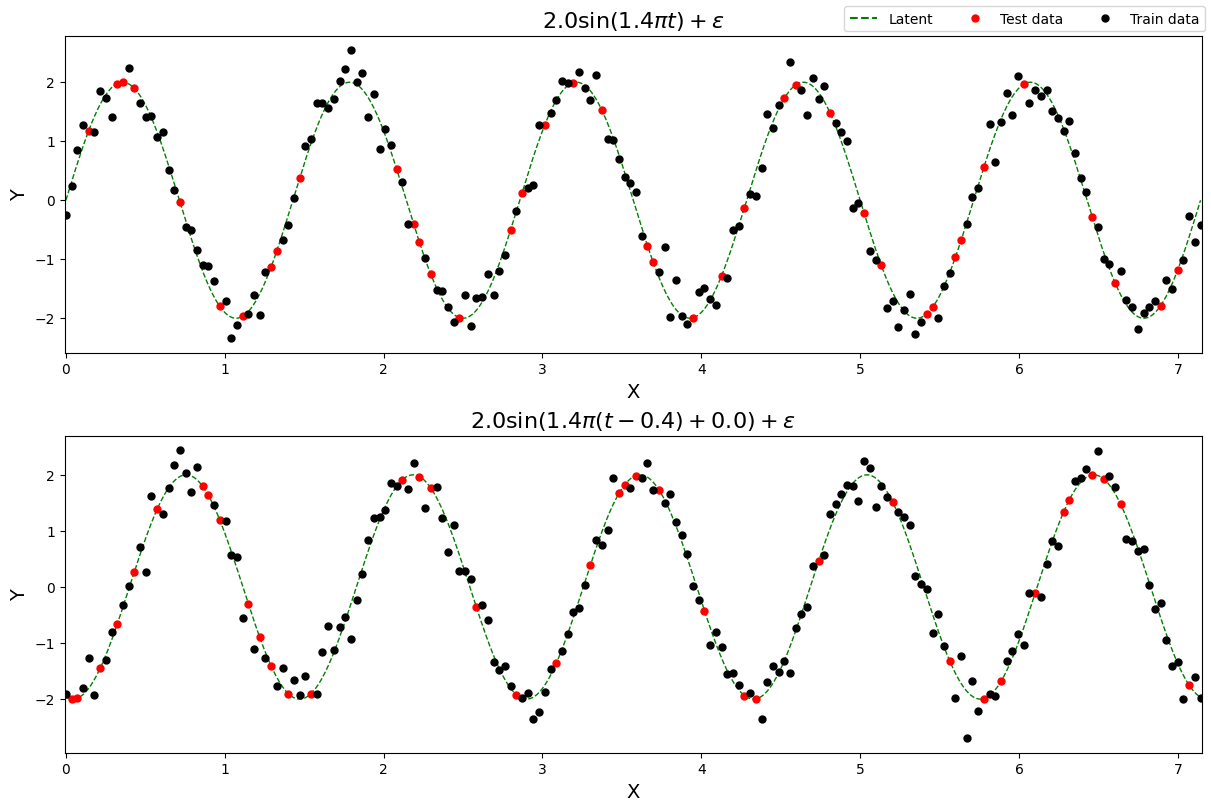

In [3]:
n_points = 200
n_cycles = 5

amplitude = 2.0
noise_sigma = 0.25

frequency = 0.7 # cycles/s
omega = 2*np.pi*frequency # radians/s
delay = 0.4 # radians
phase = 0.0

missing_pct = 0.2

t = np.linspace(0.0, n_cycles/frequency, n_points) # seconds

f1 = amplitude * np.sin(omega * t)
y1 = f1 + noise_sigma*np.random.normal(size=len(t))

f2 = amplitude * np.sin(omega * (t - delay) + phase) 
y2 = f2 + noise_sigma*np.random.normal(size=len(t))

dataset1 = mogptk.DataSet(
    mogptk.Data(t, y1, name=rf'${amplitude} \sin({2*frequency}\pi t) + \varepsilon$'),
    mogptk.Data(t, y2, name=rf'${amplitude} \sin({2*frequency}\pi (t - {delay}) + {phase}) + \varepsilon$')
)

dataset1[0].set_function(lambda t: amplitude * np.sin(omega * t) )
dataset1[1].set_function(lambda t: amplitude * np.sin(omega * (t - delay) + phase))

for data in dataset1:
    data.remove_randomly(pct=missing_pct)

dataset1.plot();

### Power Spectrum

Knowing the mathematical expression for the synthetic data, we see the expected peak at $f = 0.5$ in the periodogram.

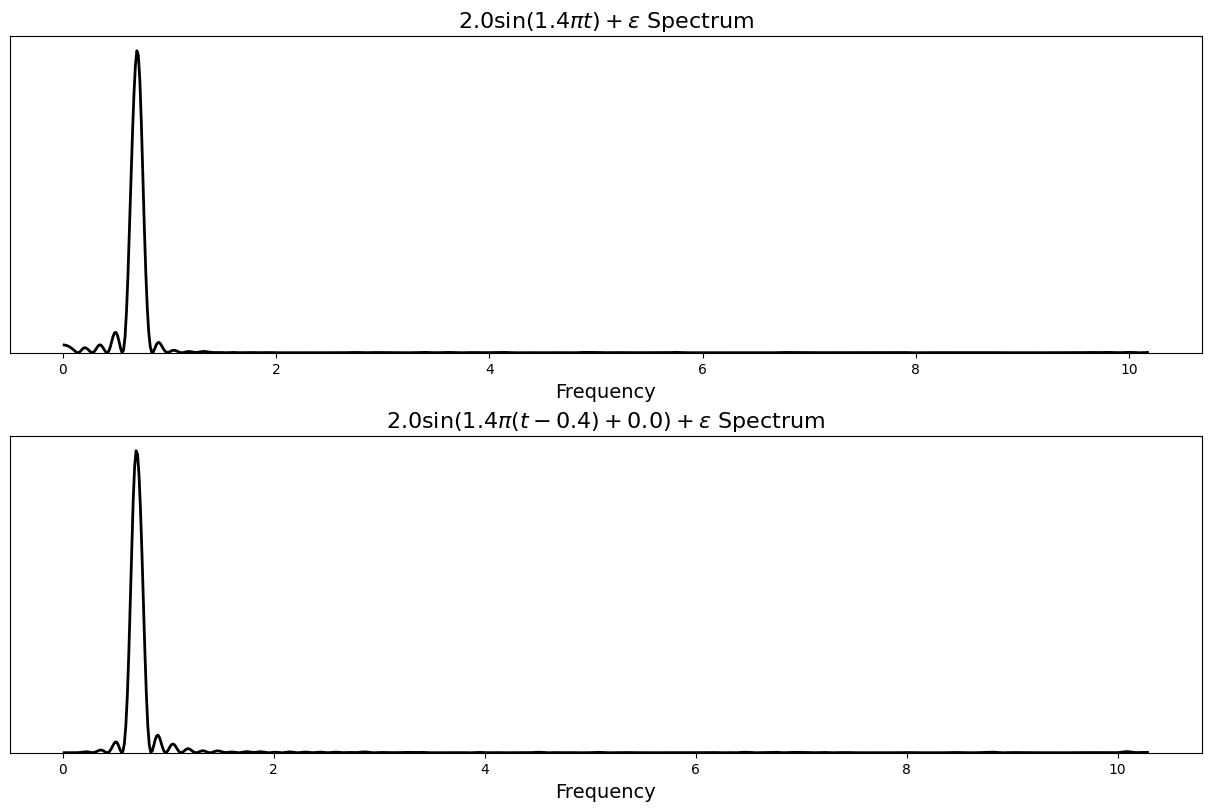

In [4]:
dataset1.plot_spectrum(method='ls'); # Lomb Scargle

## MOSM Model

### Model 1: No initialisation

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[0.6776009] [0.5644549]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.9300000000001]",[[[1.e-08]] [[1.e-08]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.68463318]] [[0.2912352 ]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.0000001 1.0000001]


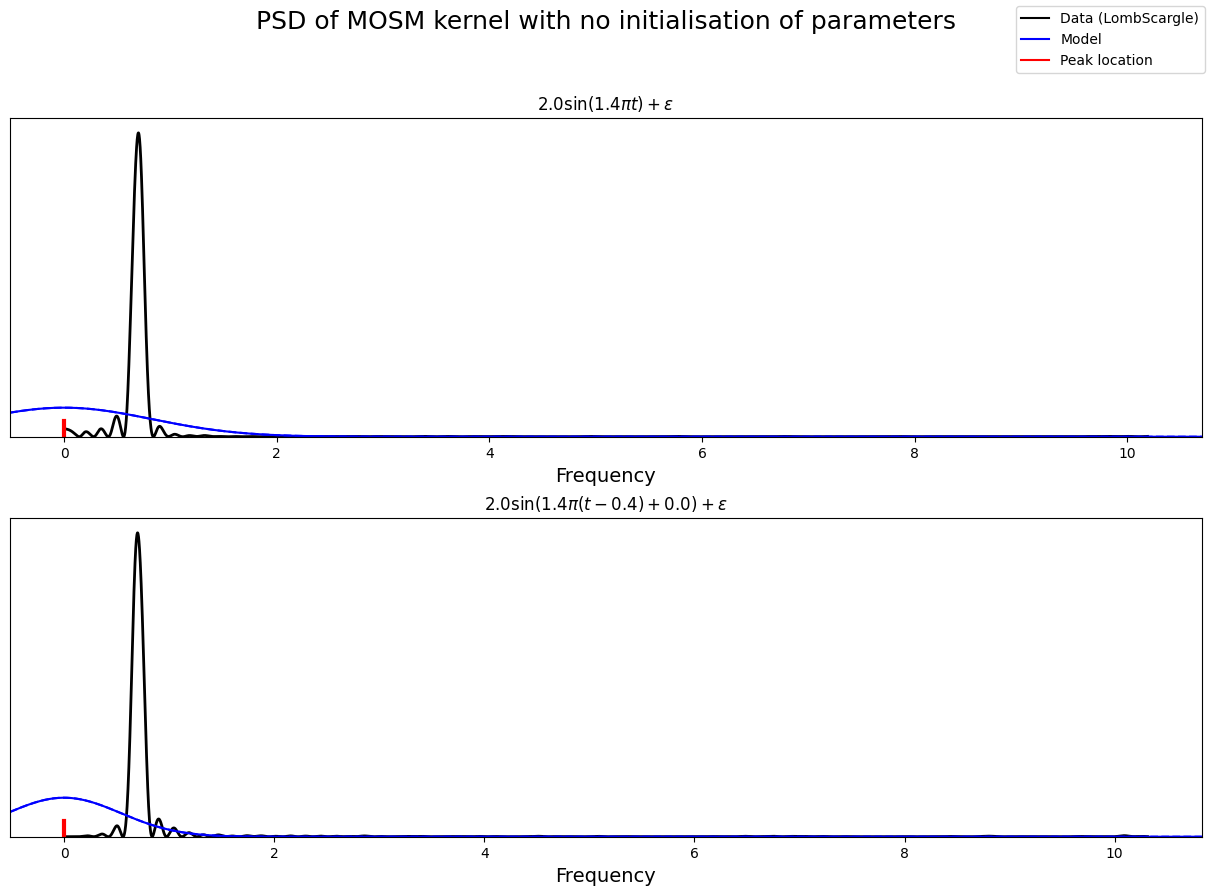

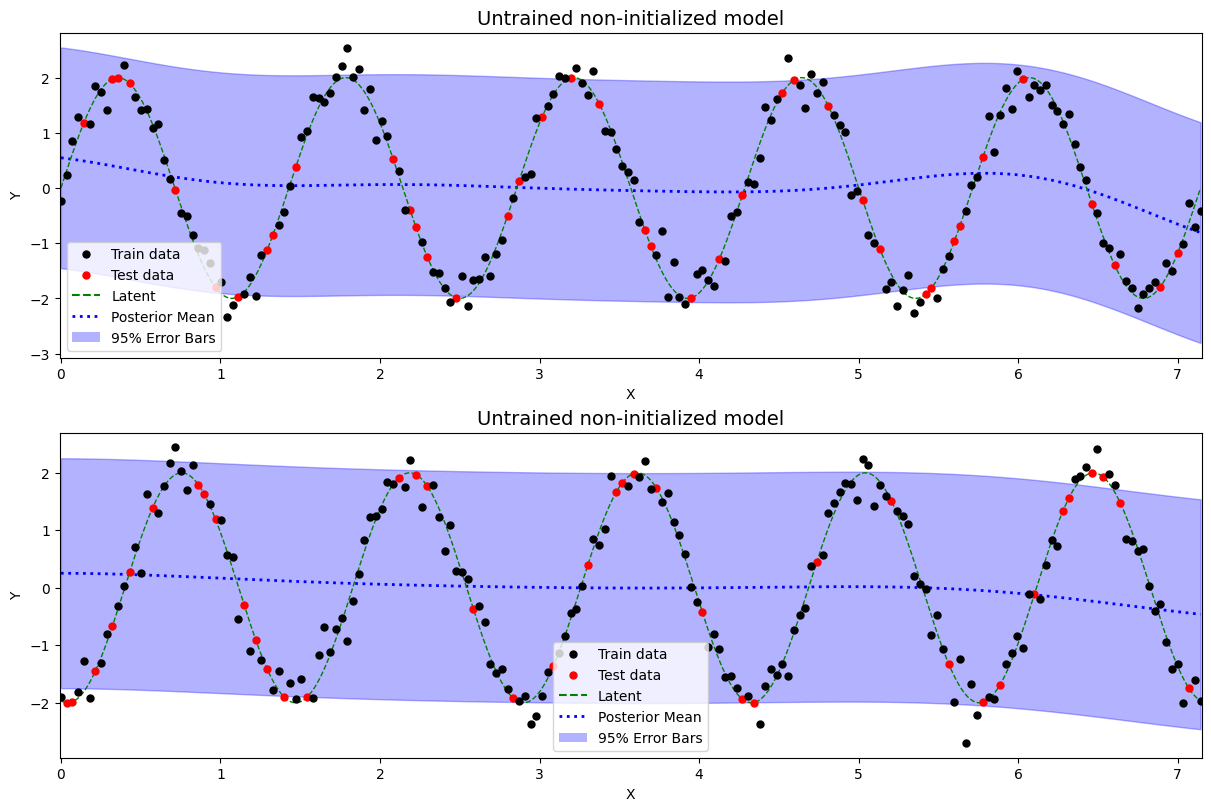

In [5]:
model1 = mogptk.MOSM(dataset1, Q=1)
model1.print_parameters()
model1.plot_spectrum(title='PSD of MOSM kernel with no initialisation of parameters');
model1.plot_prediction(title='Untrained non-initialized model');

### Model 2: Initialised Model

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[20.055363 ] [19.53356208]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.9300000000001]",[[[0.69935594]] [[0.69935594]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00284102]] [[0.00271635]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.43842002 1.40575407]


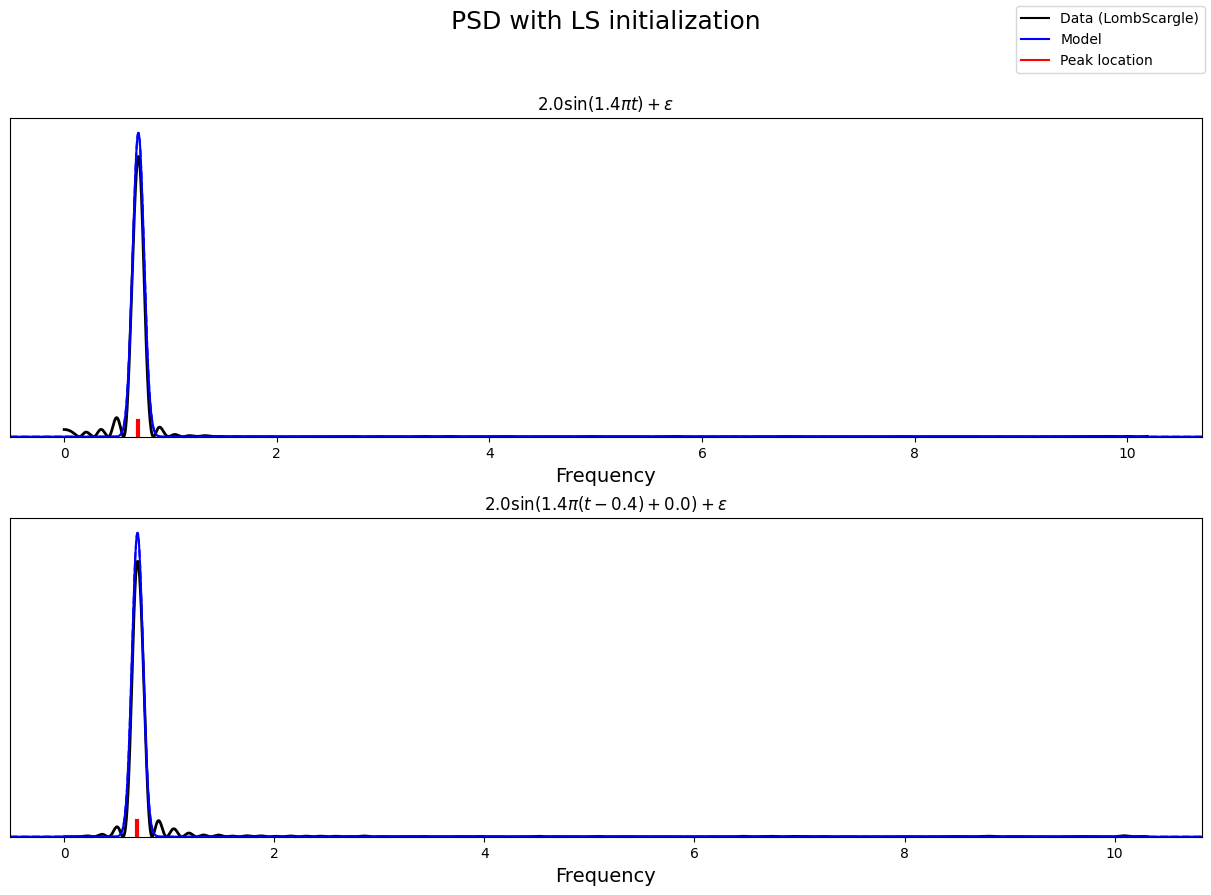

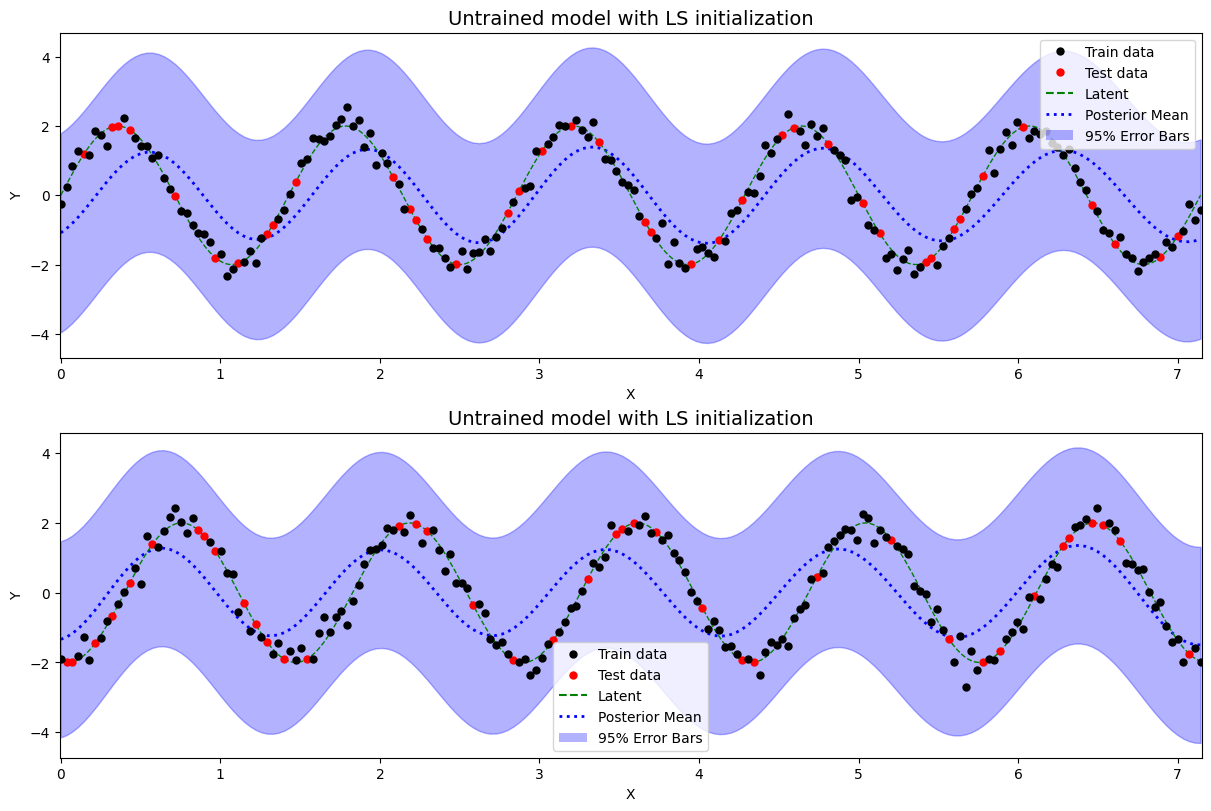

In [6]:
model2 = mogptk.MOSM(dataset1, Q=1)
model2.init_parameters(method='LS', iters=500)
model2.print_parameters()
model2.plot_spectrum(title='PSD with LS initialization');
model2.plot_prediction(title='Untrained model with LS initialization');

### Model 3: Trained Model

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 12
‣ Training points: 320
‣ Iterations: 1000


/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/mogptk/model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(self.gpr.loss())


     0/1000   0:00:06  loss=     501.755  error=    0.818193 (warmup)
   498/1000   0:00:10  loss=     409.932  error=   0.0195795
  1000/1000   0:00:14  loss=     395.374  error=   0.0164653
Optimization finished in 14.430 seconds


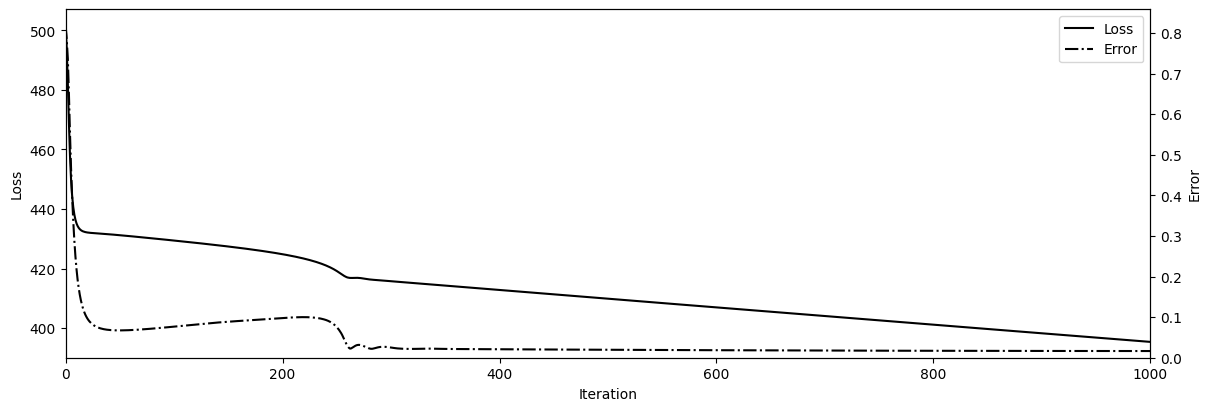

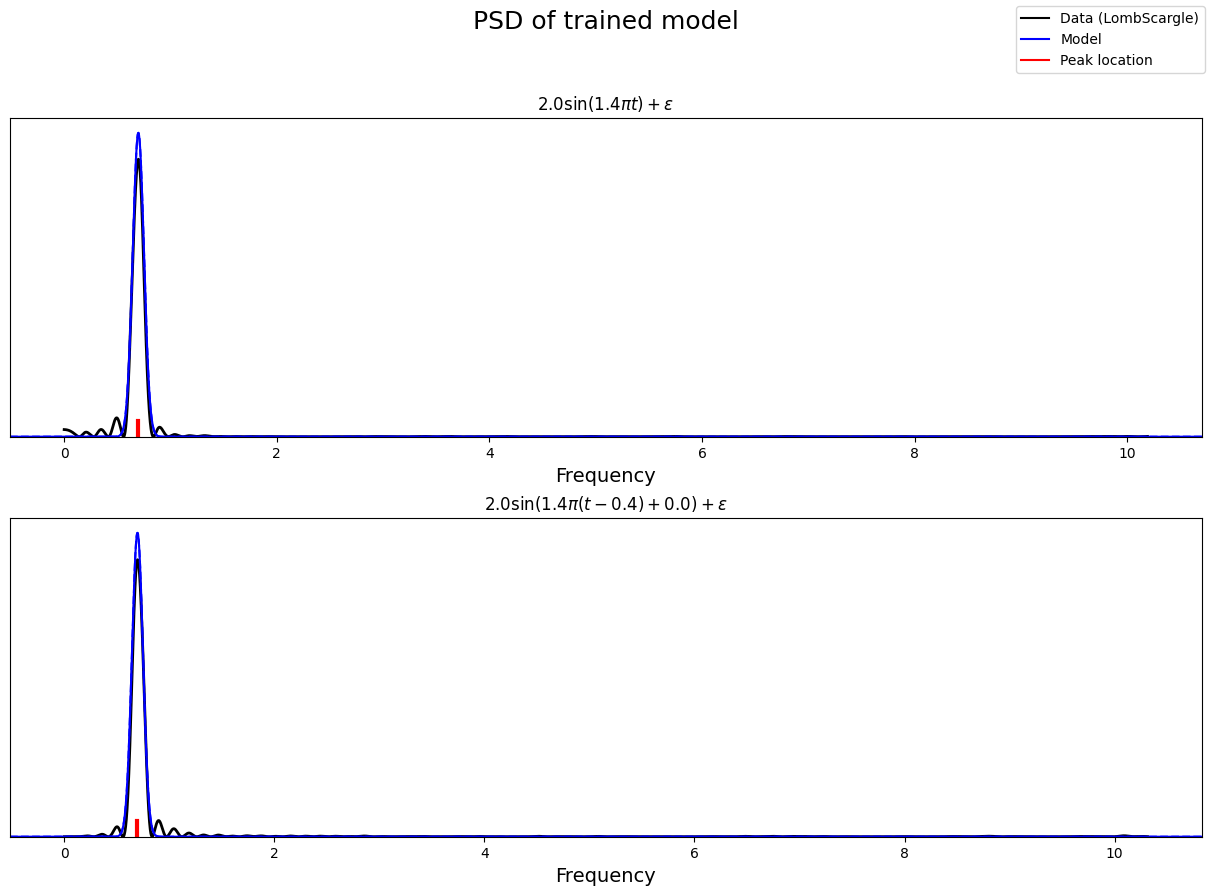

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.22387336] [19.14703842]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.9300000000001]",[[[0.69907809]] [[0.6990969 ]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.0027854 ]] [[0.00274671]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.08133278]] [[-0.08133278]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.08182658] [-0.08182658]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.30873664 1.2790656 ]


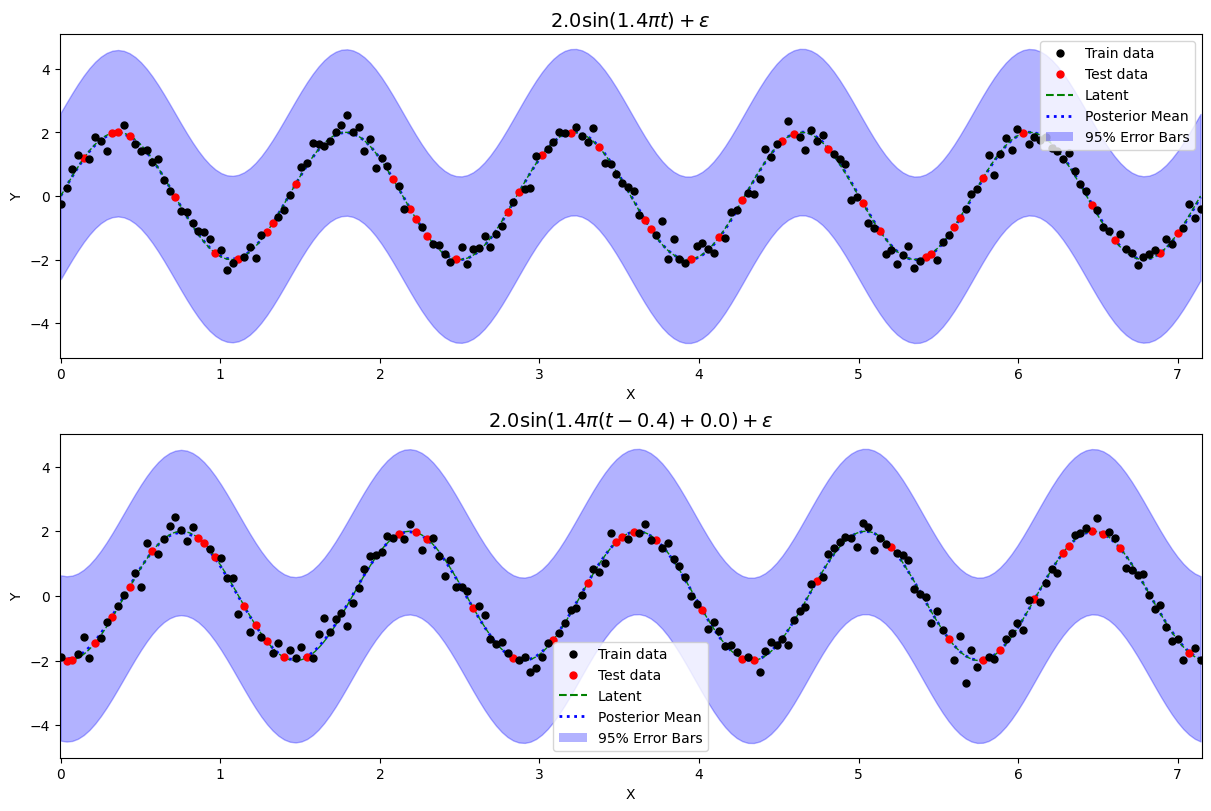

In [7]:
model3 = mogptk.MOSM(dataset1, Q=1)
model3.init_parameters(method='LS', iters=500)
model3.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model3.plot_spectrum(title='PSD of trained model');
model3.plot_prediction();
model3.print_parameters()

### Model 4: Retrain with delay parameter $\theta_{12}$ fixed at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 320
‣ Iterations: 1000
     0/1000   0:00:00  loss=     501.755  error=    0.818193 (warmup)
  1000/1000   0:00:09  loss=     395.359  error=   0.0164703
Optimization finished in 9.156 seconds


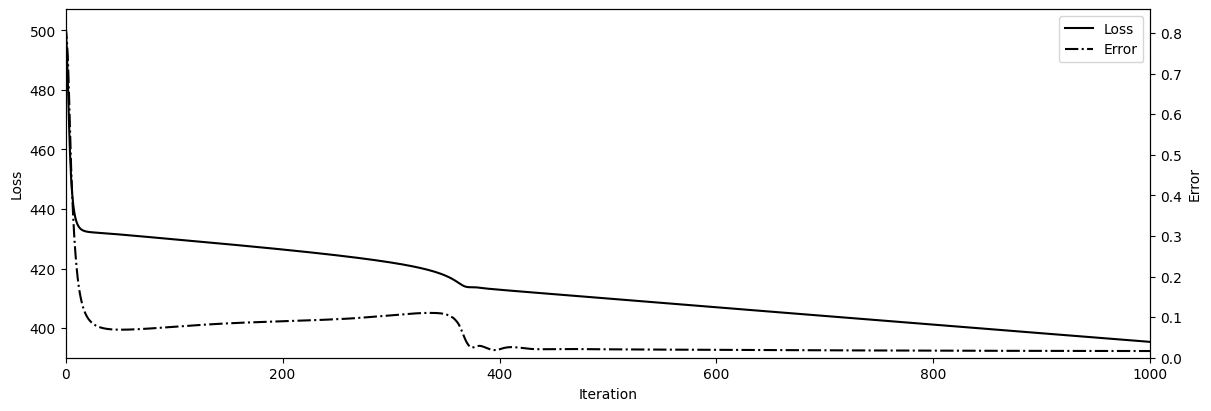

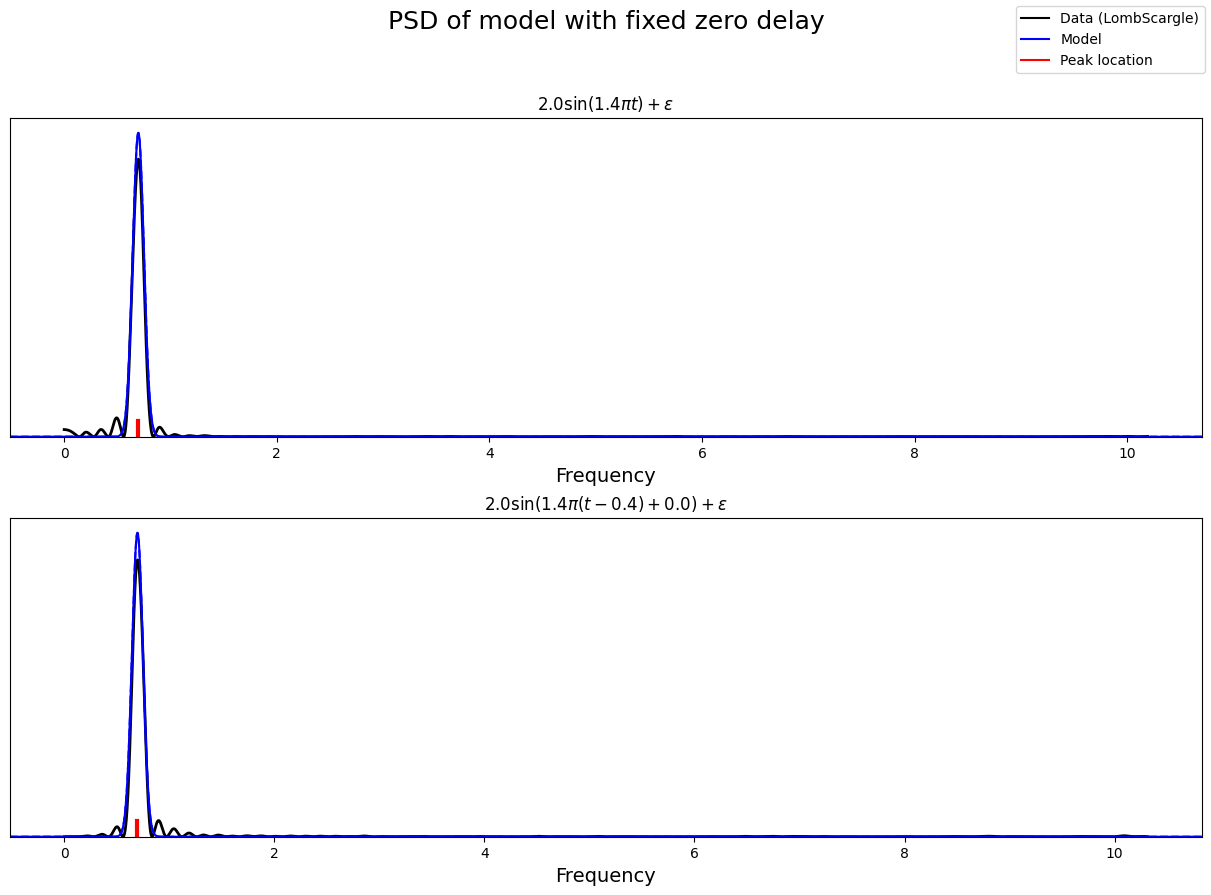

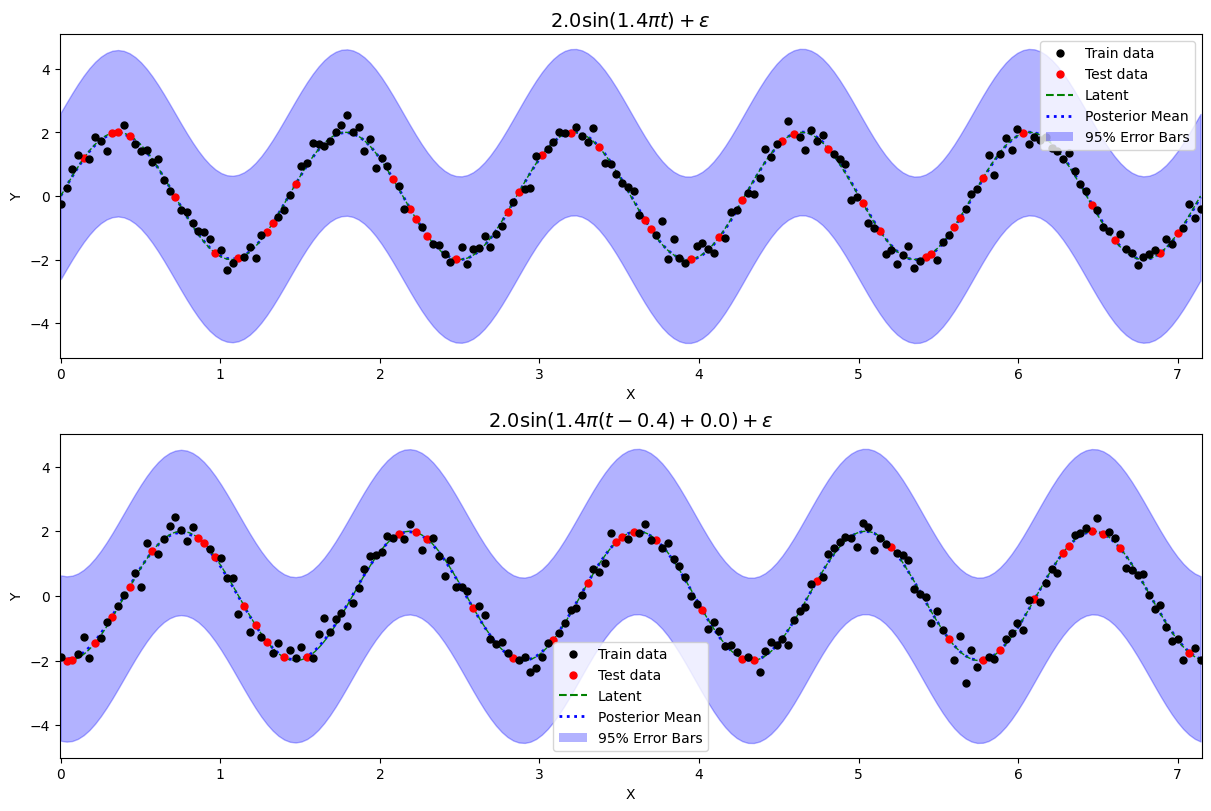

In [8]:
model4 = mogptk.MOSM(dataset1, Q=1)
model4.gpr.kernel.delay.assign(np.zeros((2,1)), lower=0, upper=0, train=False)
model4.init_parameters(method='LS', iters=500)
model4.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model4.plot_spectrum(title='PSD of model with fixed zero delay');
model4.plot_prediction();

### Model 5: Retrain with phase parameter $\phi_{12}$ fixed at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 320
‣ Iterations: 1000
     0/1000   0:00:00  loss=     501.755  error=    0.818193 (warmup)
  1000/1000   0:00:07  loss=     395.371  error=   0.0166035
Optimization finished in 7.792 seconds


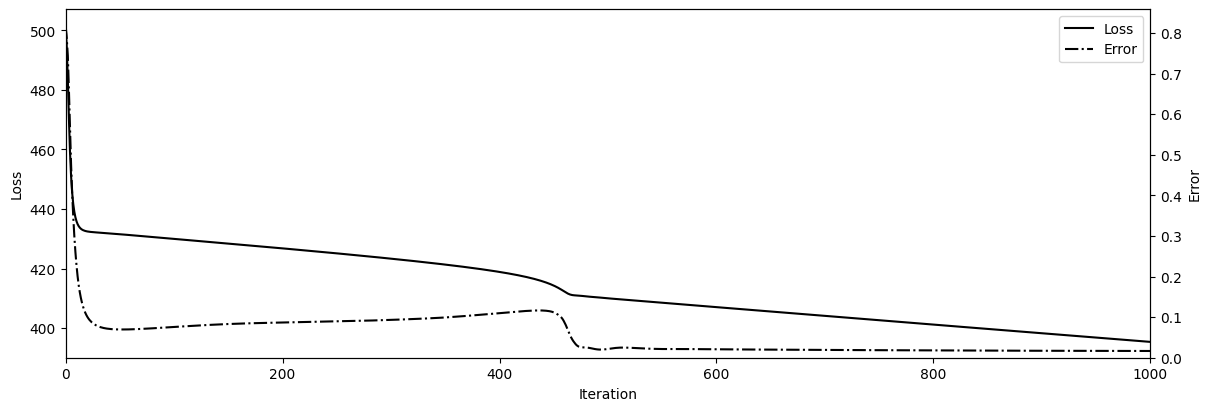

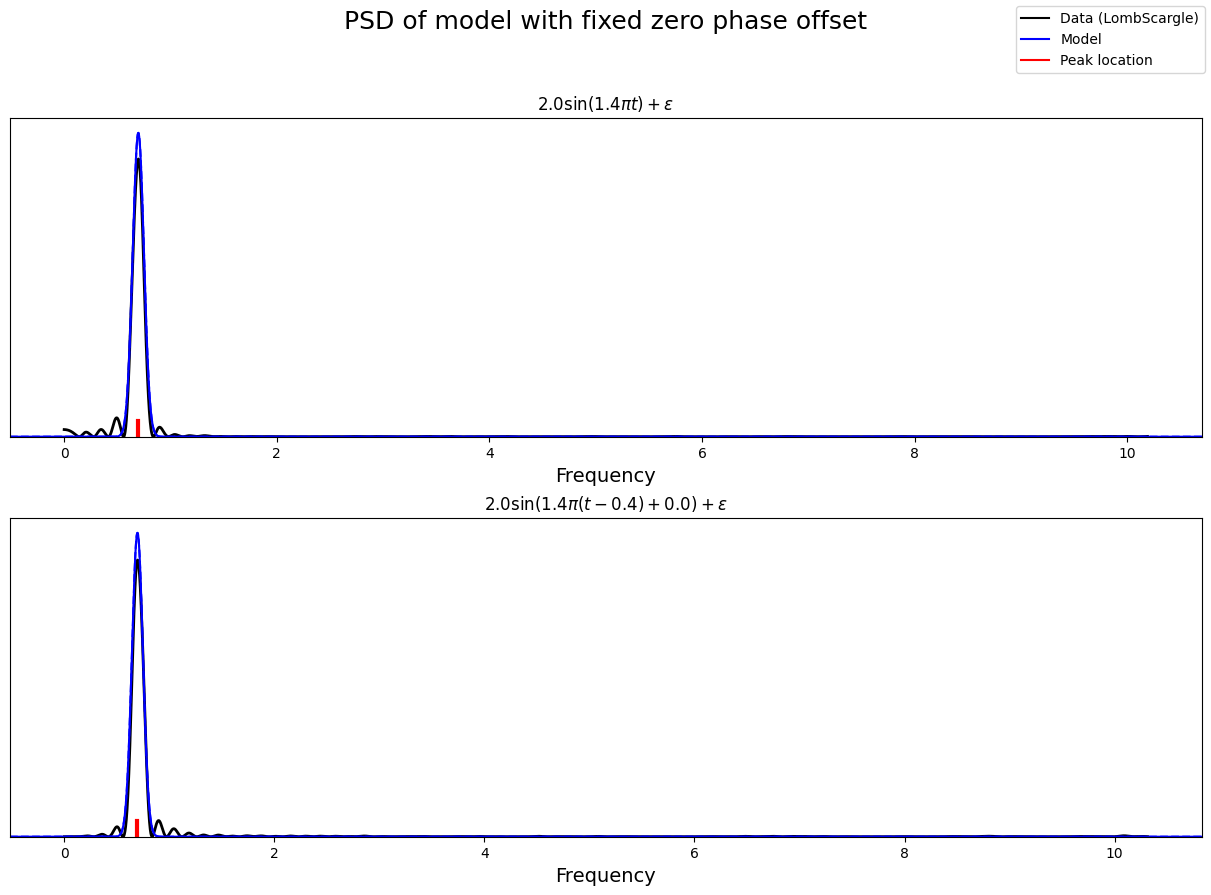

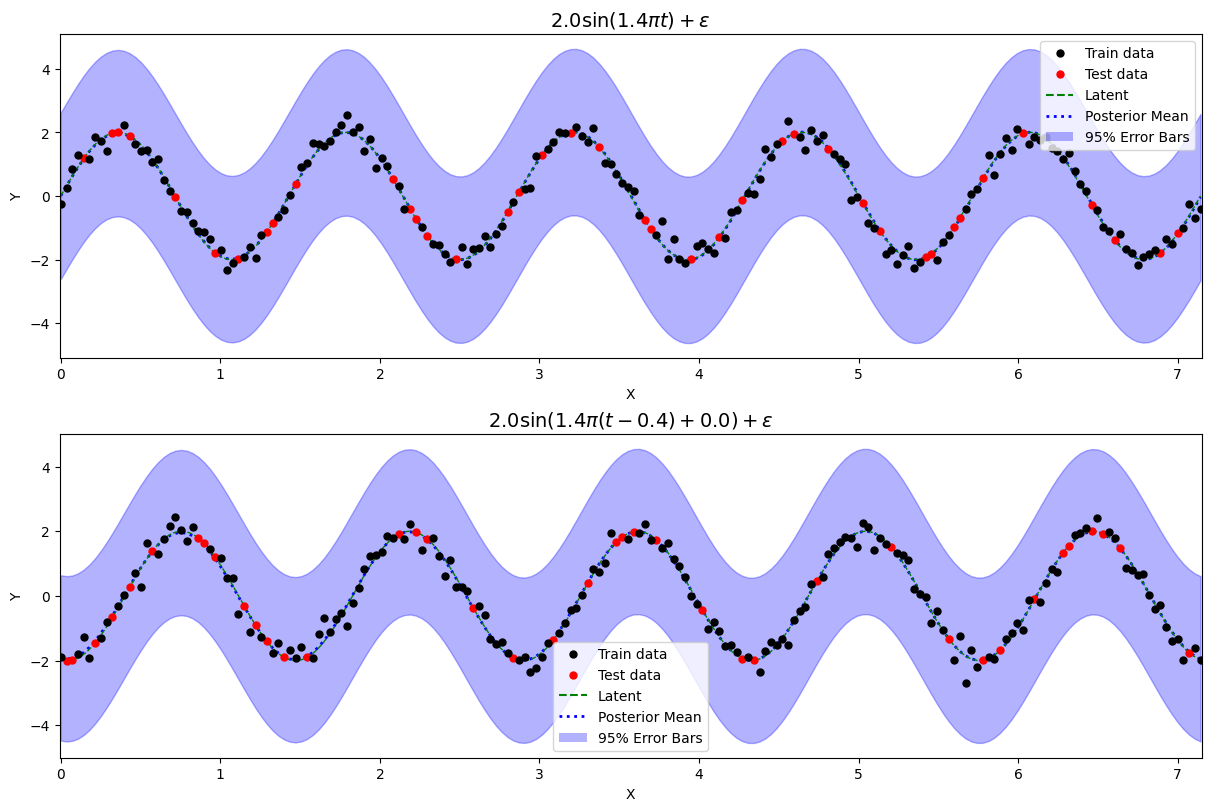

In [9]:
model5 = mogptk.MOSM(dataset1, Q=1)
model5.gpr.kernel.phase.assign(np.zeros((2,1)), lower=0, upper=0, train=False)
model5.init_parameters(method='LS', iters=500)
model5.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model5.plot_spectrum(title='PSD of model with fixed zero phase offset');
model5.plot_prediction();

## Compare results

### Model 4: $\theta_{12}$ fixed at zero, fitting phase shift $\phi_{12}$

Data generating process: $A \sin(2\pi f[t - \textrm{delay}]) = 2.0 \sin(2\pi[0.7t - 0.28])$

Expecting $\phi_1 - \phi_2 = \phi_{12} = 0.28$

In [10]:
model4.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.20343248] [19.12560673]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.9300000000001]",[[[0.69893286]] [[0.69895498]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00278734]] [[0.00274365]]]
MultiOutputSpectralMixtureKernel.delay,fixed,[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.13872729] [-0.13872729]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.3086652 1.27900111]


### Model 5: $\phi_{12}$ fixed at zero, fitting delay $\theta_{12}$

Data generating process: $A \sin(2\pi f[ t - \textrm{delay}]) = 2.0 \sin(2\pi (0.7)[t - 0.4])$

Expecting $\theta_1 - \theta_2 = \theta_{12} = 0.4$

In [11]:
model5.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.18439203] [19.11722851]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.9300000000001]",[[[0.69887277]] [[0.6988981 ]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00278973]] [[0.00274001]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.19829752]] [[-0.19829752]]]
MultiOutputSpectralMixtureKernel.phase,fixed,[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.30865966 1.27899602]


## Correlation between bands

array([[ 1.        , -0.17261711],
       [-0.17261711,  1.        ]])

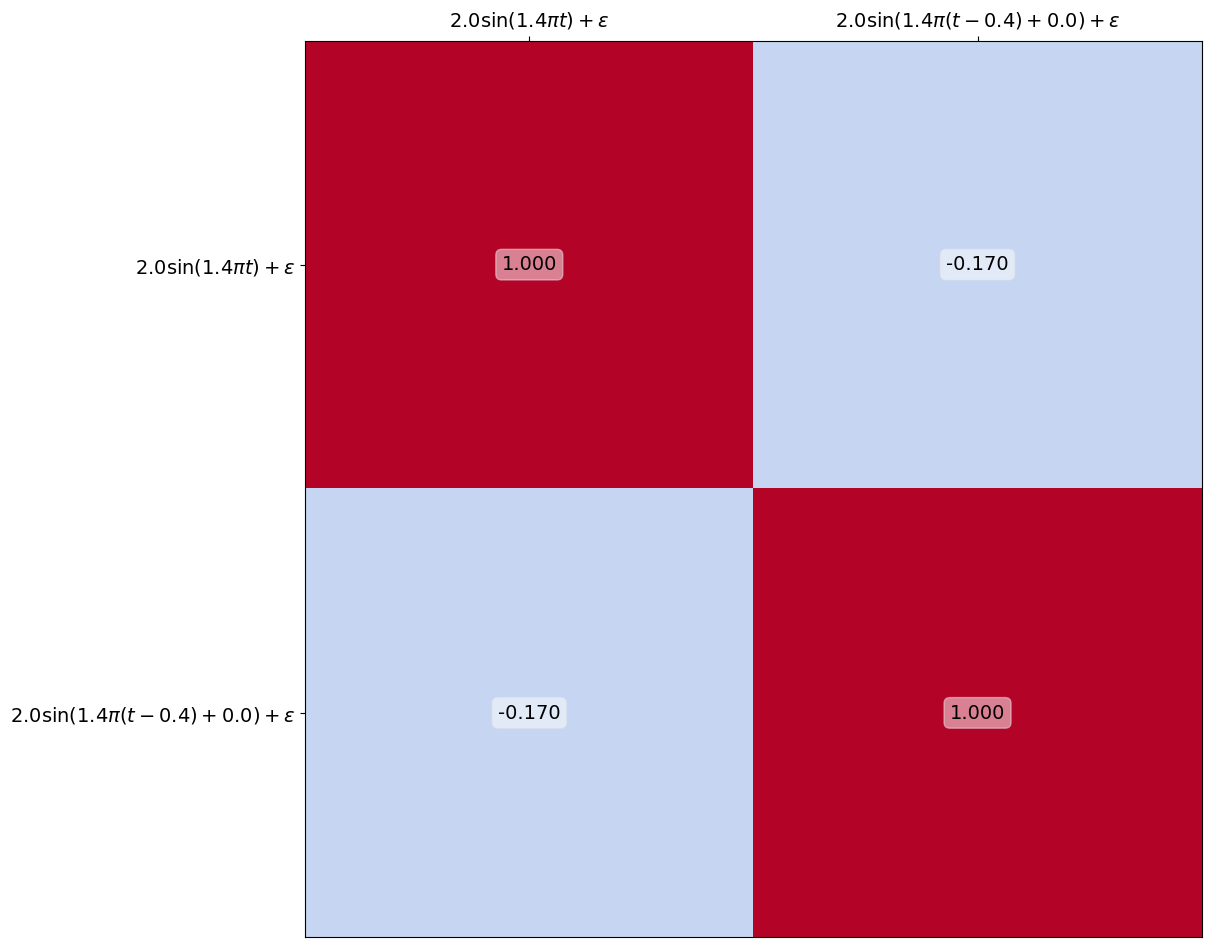

In [12]:
model5.plot_correlation();
np.corrcoef(y1, y2)

Simple comparison of correlations between the bands in the ground truth data and the fitted data are close: $-0.1805$ vs $-0.172$.

## 